In [1]:
# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/lalitraos/simulated-student-performance-data/StudentsPerformance.csv')

# View the first 5 rows to confirm it loaded successfully
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# P1 Student Performance

Generating Student Data...
Processing Data...
Calculating Statistics...
Generating Dashboard...

FINAL SUMMARY REPORT

Class Subject Statistics:
         Math  Physics  Chemistry  English  Biology
mean    65.50    65.74      68.20    66.30    68.78
median  67.00    65.00      66.00    66.00    71.00
std     18.28    20.57      19.31    21.43    19.77

Top Student: Student_6 (449 marks)
Lowest Student: Student_21 (240 marks)

Data exported successfully to student_performance_processed.csv


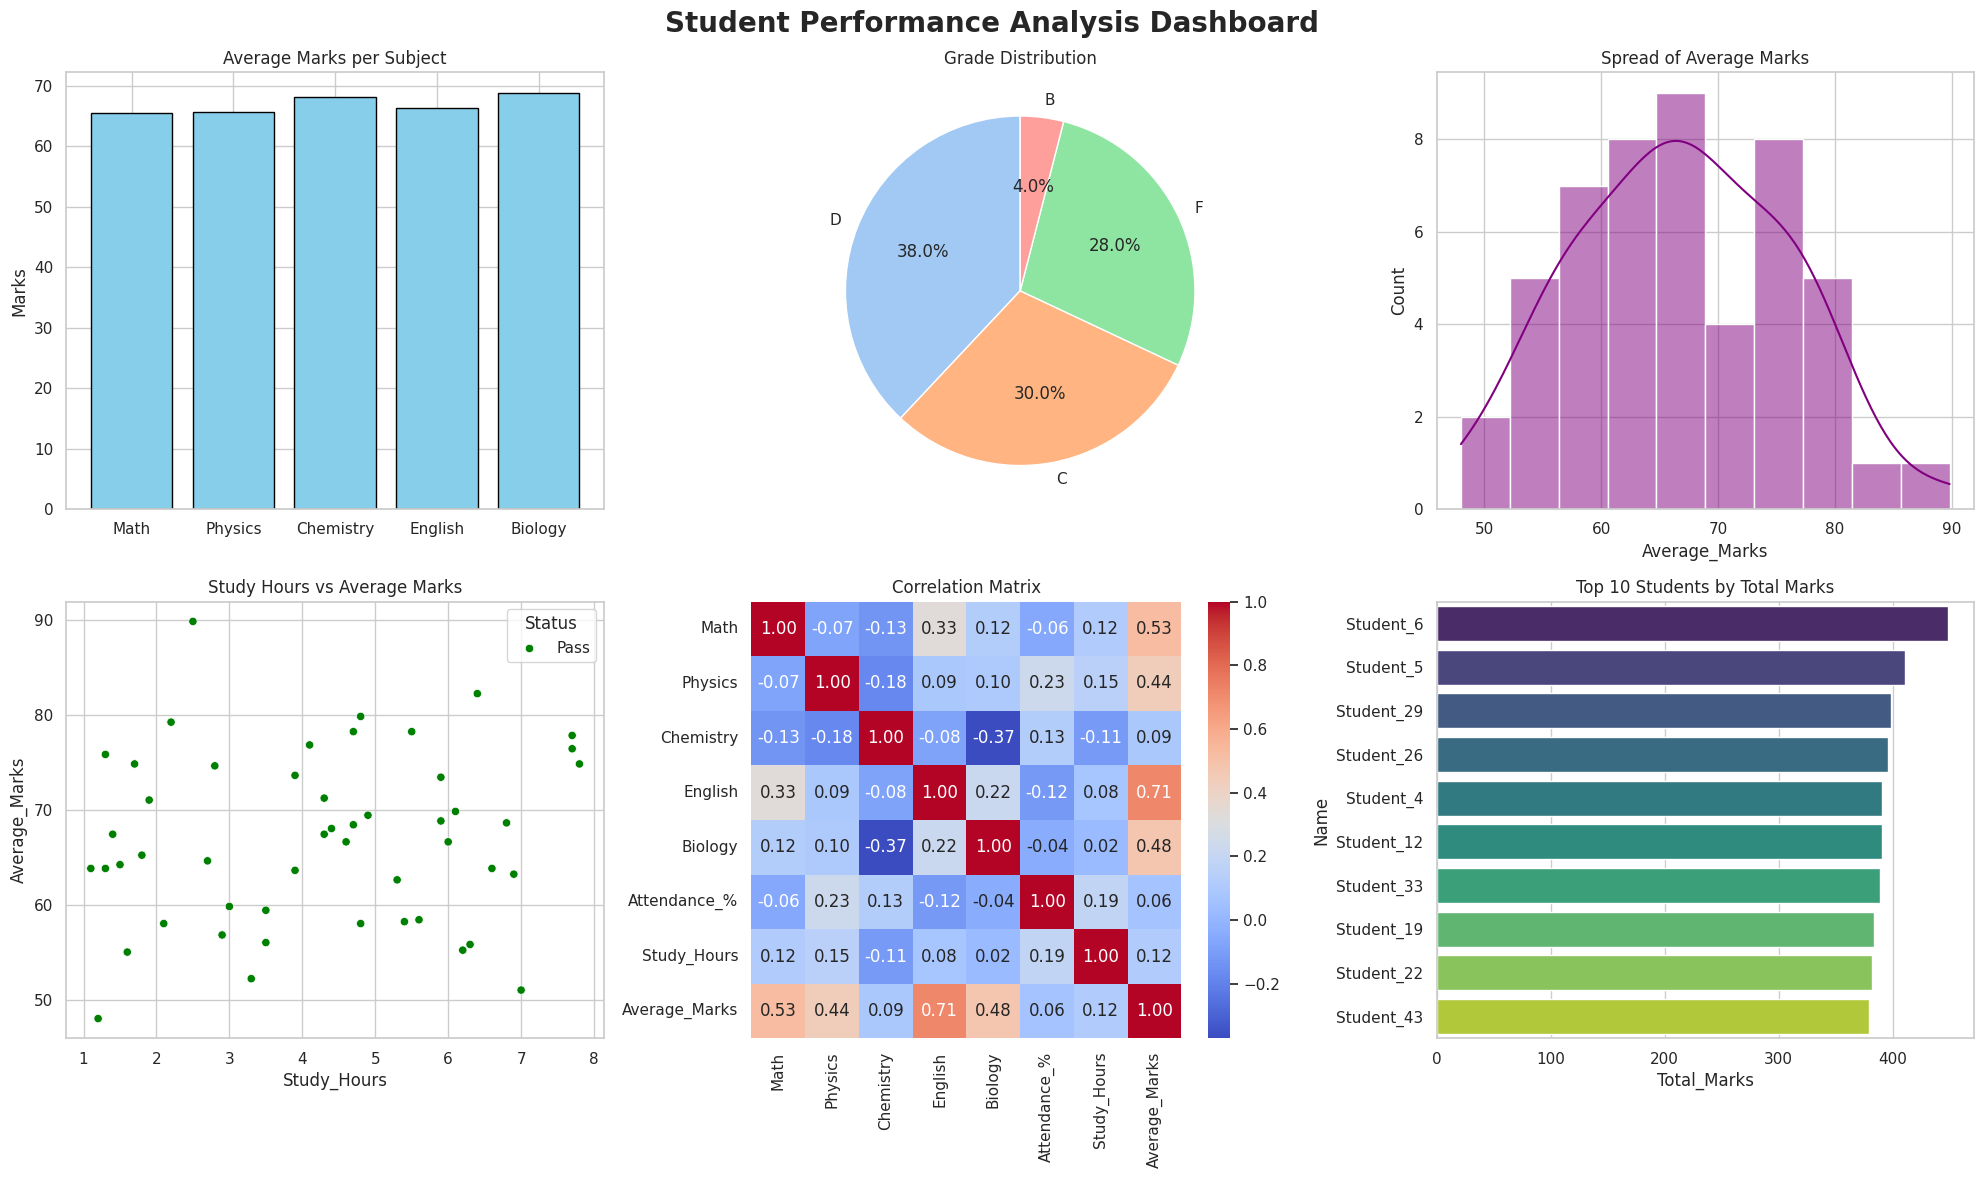

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# Module 1 - Data Generation (NumPy)
# ---------------------------------------------------------
print("Generating Student Data...")
np.random.seed(42) # For reproducibility
num_students = 50
names = [f"Student_{i}" for i in range(1, num_students + 1)]
subjects = ['Math', 'Physics', 'Chemistry', 'English', 'Biology']

# Generate random marks, attendance, and study hours
marks = np.random.randint(35, 100, size=(num_students, len(subjects)))
attendance = np.random.uniform(50, 100, size=num_students).round(2)
study_hours = np.random.uniform(1, 8, size=num_students).round(1)

# ---------------------------------------------------------
# Module 2 - Data Processing (Pandas)
# ---------------------------------------------------------
print("Processing Data...")
df = pd.DataFrame(marks, columns=subjects)
df.insert(0, 'Name', names)
df['Attendance_%'] = attendance
df['Study_Hours'] = study_hours

# Calculate total and average
df['Total_Marks'] = df[subjects].sum(axis=1)
df['Average_Marks'] = df[subjects].mean(axis=1).round(2)

# Assign grades and pass/fail status
def assign_grade(avg):
    if avg >= 90: return 'A'
    elif avg >= 80: return 'B'
    elif avg >= 70: return 'C'
    elif avg >= 60: return 'D'
    else: return 'F'

df['Grade'] = df['Average_Marks'].apply(assign_grade)
df['Status'] = np.where(df['Average_Marks'] >= 40, 'Pass', 'Fail')

# ---------------------------------------------------------
# Module 3 - Statistical Analysis (NumPy + Pandas)
# ---------------------------------------------------------
print("Calculating Statistics...")
# Key statistics
class_stats = df[subjects].agg(['mean', 'median', 'std']).round(2)
top_student = df.loc[df['Total_Marks'].idxmax()]
lowest_student = df.loc[df['Total_Marks'].idxmin()]
subject_averages = df[subjects].mean()

# ---------------------------------------------------------
# Module 4 - Visualization (Matplotlib)
# ---------------------------------------------------------
print("Generating Dashboard...")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Student Performance Analysis Dashboard', fontsize=20, weight='bold')

# 1. Bar chart: Subject Averages
axes[0, 0].bar(subjects, subject_averages, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Average Marks per Subject')
axes[0, 0].set_ylabel('Marks')

# 2. Pie chart: Grade Distribution
grade_counts = df['Grade'].value_counts()
axes[0, 1].pie(grade_counts, labels=grade_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
axes[0, 1].set_title('Grade Distribution')

# 3. Histogram: Marks Spread
sns.histplot(df['Average_Marks'], bins=10, kde=True, ax=axes[0, 2], color='purple')
axes[0, 2].set_title('Spread of Average Marks')

# 4. Scatter plot: Study Hours vs Marks
sns.scatterplot(data=df, x='Study_Hours', y='Average_Marks', hue='Status', ax=axes[1, 0], palette={'Pass':'green', 'Fail':'red'})
axes[1, 0].set_title('Study Hours vs Average Marks')

# 5. Correlation Heatmap
corr_data = df[subjects + ['Attendance_%', 'Study_Hours', 'Average_Marks']].corr()
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title('Correlation Matrix')

# 6. Horizontal Bar: Top 10 Students
top_10 = df.nlargest(10, 'Total_Marks')
sns.barplot(data=top_10, x='Total_Marks', y='Name', ax=axes[1, 2], palette='viridis')
axes[1, 2].set_title('Top 10 Students by Total Marks')

plt.tight_layout()
plt.savefig('student_dashboard.png')
# plt.show() # Uncomment to view inline

# ---------------------------------------------------------
# Module 5 - Report & CSV Export
# ---------------------------------------------------------
print("\n" + "="*40)
print("FINAL SUMMARY REPORT")
print("="*40)
print("\nClass Subject Statistics:")
print(class_stats)
print(f"\nTop Student: {top_student['Name']} ({top_student['Total_Marks']} marks)")
print(f"Lowest Student: {lowest_student['Name']} ({lowest_student['Total_Marks']} marks)")

# Export to CSV
export_path = 'student_performance_processed.csv'
df.to_csv(export_path, index=False)
print(f"\nData exported successfully to {export_path}")
